
Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [14]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split,RepeatedKFold,GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor, export_graphviz 
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import get_scorer_names

In [15]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## 2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed. 3 Check for missing variables and correct as needed.

In [16]:
def data_cleaning(df, drop_col):
    df.drop(columns=drop_col, inplace=True, errors="ignore")
    object_cols=df.select_dtypes(include=['object']).columns
    for col in object_cols:
        df[col]=df[col].astype('category')
    df = df.dropna()
    
    return df
movie_metadata = data_cleaning(movie_metadata, ['plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'])
movie_titles = movie_metadata["movie_title"]
movie_metadata = movie_metadata.drop(columns=["movie_title"])
encoder = OneHotEncoder(sparse_output=False)

In [17]:
movie_titles.shape

(3769,)

In [18]:
#import the encoders
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

## encode directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

## encode title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

## encode first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

# encode content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)

# encode country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

# encode language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

# encode color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')

#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

# Categorize imdb_score into three classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 8.0 else "average" if x > 6.0 else "low"
)

#print(movie_metadata["imdb_score"].value_counts())

movie_metadata["imdb_score"] = OrdinalEncoder().fit_transform(movie_metadata[['imdb_score']])

#print(movie_metadata["imdb_score"].value_counts())

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step. 5 Determine the variance of the target variable, is it normally distributed? If not, you may want to transform the target variable. Why might this be important?

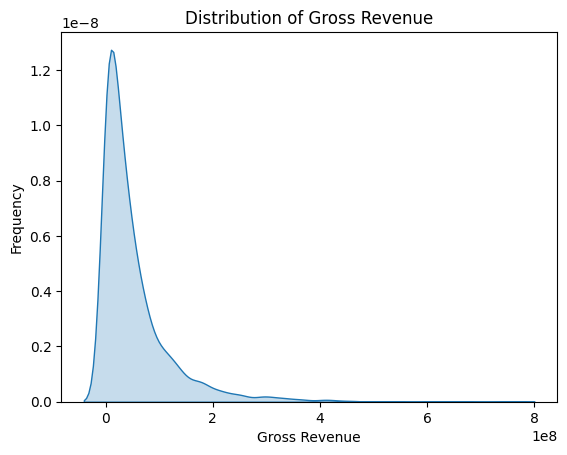

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(movie_metadata, x ='gross', fill=True, common_norm=False)
plt.title('Distribution of Gross Revenue')
plt.xlabel('Gross Revenue')
plt.ylabel('Frequency')
plt.show()

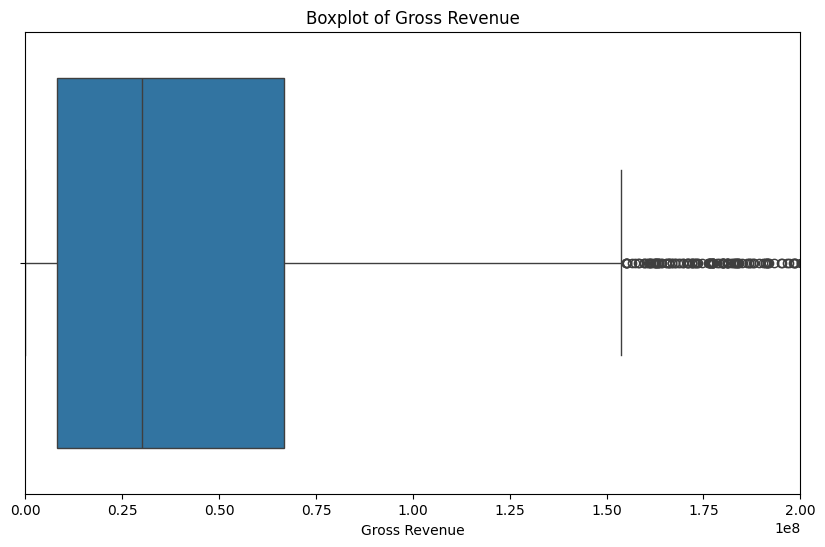

Number of outliers:  295


In [20]:
# check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=movie_metadata['gross'])
plt.title('Boxplot of Gross Revenue')
plt.xlabel('Gross Revenue')
plt.xlim(0, 2e8)
plt.show()

# count the number of outliers
outliers = movie_metadata[(movie_metadata['gross'] > 1.5e8)]
print("Number of outliers: ", len(outliers))

In [21]:
#movie_metadata = movie_metadata[movie_metadata['gross'] <= 1.5e8]

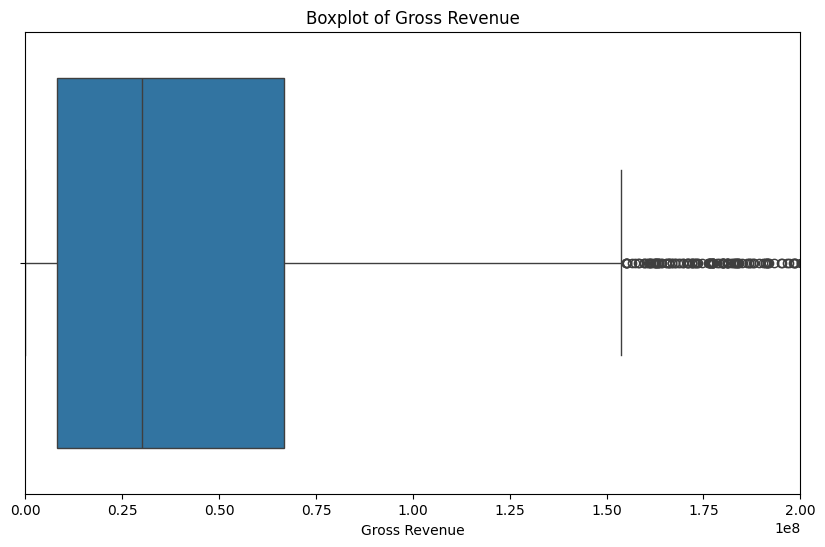

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=movie_metadata['gross'])
plt.title('Boxplot of Gross Revenue')
plt.xlabel('Gross Revenue')
plt.xlim(0, 2e8)
plt.show()

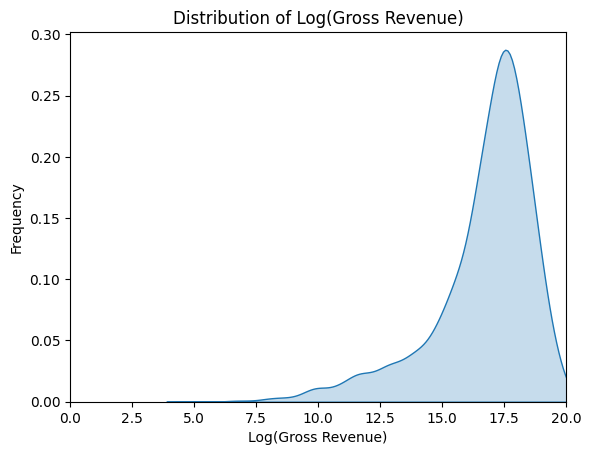

In [23]:
movie_metadata['Log_Gross'] = np.log(movie_metadata['gross'])
# Drop gross revenue column
movie_metadata = movie_metadata.drop(columns=['gross'])
# Check the distribution of the target variable
sns.kdeplot(movie_metadata, x ='Log_Gross', fill=True, common_norm=False)
plt.title('Distribution of Log(Gross Revenue)')
plt.xlabel('Log(Gross Revenue)')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

## 6 Split your data into test, tune, and train. (80/10/10)

In [24]:
X = movie_metadata.drop('Log_Gross', axis=1)
y = movie_metadata['Log_Gross']

In [25]:
X.shape

(3769, 31)

In [26]:
movie_titles.shape

(3769,)

In [27]:
X_train, X_test, y_train, y_test, title_train, title_test= train_test_split(X, y, movie_titles, train_size=0.80, random_state=21)
X_tune, X_test, y_tune, y_test, title_tune, title_test = train_test_split(X_test,y_test, title_test, train_size = 0.50, random_state=49)

## 7 Create the kfold object for cross validation.

In [28]:
kf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    #"min_samples_leaf":[1,2,3,4,5,6,7,8,9,10],
    #"min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    #"max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] 
    #'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    #'ccp_alpha':[.001,.01,.1]
        }

## 8 Create the scoring metric (several measures) you will use to evaluate your model and the max depth hyperparameter.

In [29]:
print(get_scorer_names())  # find them
scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

## 9 Build the regression tree object. 

In [30]:
reg=DecisionTreeRegressor(random_state=30)
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')

## 10 Fit the model to the training data.

In [31]:
model = search.fit(X_train, y_train)

In [32]:
# best hyperparameters
print("Best Hyperparameters: ", model.best_params_)
# best score
print("Best Score: ", model.best_score_)

Best Hyperparameters:  {'max_depth': 5}
Best Score:  0.4960551695188464


## 11 Explore the results of the model. Print the output of the grid search. What is the best parameter and score?

In [33]:
# Print the results of the grid search
print(pd.DataFrame(model.cv_results_))

best=model.best_estimator_
print(best)

# Print the best hyperparameters
print(model.best_params_)

# Print the best score
print(model.best_score_)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.009005      0.008203         0.002881        0.001464   
1        0.008169      0.001418         0.002160        0.000615   
2        0.016145      0.004568         0.003640        0.001762   
3        0.022756      0.008869         0.004381        0.004073   
4        0.023307      0.003718         0.003724        0.002118   
5        0.029904      0.006889         0.003933        0.002008   
6        0.032051      0.004185         0.003884        0.002666   
7        0.034336      0.003866         0.003562        0.002305   
8        0.038916      0.005689         0.003196        0.000597   
9        0.044349      0.006466         0.004069        0.003617   
10       0.046797      0.006932         0.003280        0.000799   
11       0.053623      0.008292         0.003562        0.001095   
12       0.054412      0.005388         0.003646        0.001231   
13       0.057271      0.004649         0.003628

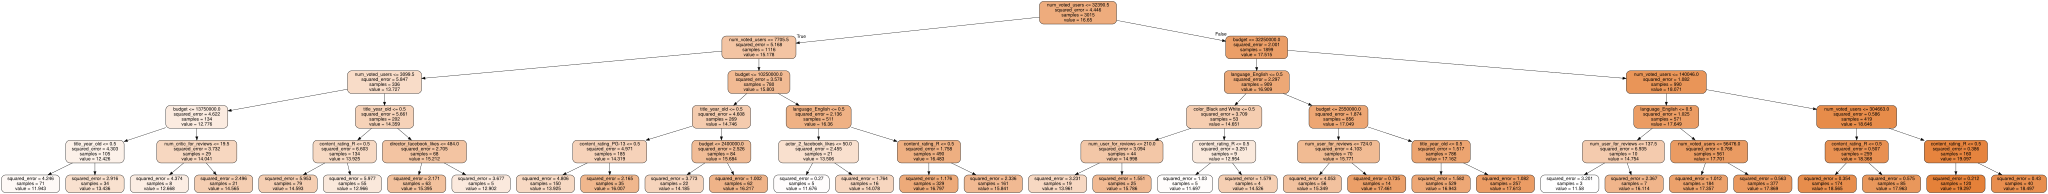

In [34]:
import graphviz

dot_data = export_graphviz(best, out_file=None,
               feature_names=X.columns,  # feature names from dataset
               filled=True, 
               rounded=True) 
               
graph = graphviz.Source(dot_data)
graph

## 12 Which variables appear to be contributing the most (variable importance)

In [35]:
varimp=pd.DataFrame(best.feature_importances_,index = X_train.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                              importance
num_voted_users                 0.656792
budget                          0.164977
language_English                0.067276
title_year_old                  0.038025
content_rating_R                0.029582
num_user_for_reviews            0.015771
content_rating_PG-13            0.015019
color_Black and White           0.003812
director_facebook_likes         0.003517
actor_2_facebook_likes          0.002683
num_critic_for_reviews          0.002546
country_Other                   0.000000
country_Big Country Producer    0.000000
language_French                 0.000000
language_Other                  0.000000
content_rating_Other            0.000000
actor_1_name_Other              0.000000
actor_1_name_Famous             0.000000
director_name_Other             0.000000
title_year_new                  0.000000
title_year_middle               0.000000
duration                        0.000000
director_name_Famous            0.000000
movie_facebook_l

## 13 Create a model object using the best model hyperparameter value from the trained regression tree.

In [36]:
best=model.best_estimator_

## 14 Using the best model predict on the tune data and print out the results.

In [37]:
y_pred = best.predict(X_tune)
print(y_pred)

[19.29717403 19.29717403 16.94334417 11.94293309 17.3572758  11.94293309
 16.21661236 16.94334417 17.3572758  19.29717403 11.94293309 18.56528619
 16.94334417 16.7965728  11.94293309 17.86863924 16.94334417 18.56528619
 16.94334417 17.6134514  16.94334417 17.6134514  14.59310865 16.7965728
 16.94334417 17.6134514  16.7965728  15.34910522 17.86863924 17.3572758
 14.59310865 17.96301776 17.86863924 13.92538019 15.34910522 18.56528619
 16.94334417 16.94334417 17.6134514  16.94334417 16.94334417 16.21661236
 16.94334417 17.86863924 16.7965728  15.84141866 16.94334417 16.7965728
 17.6134514  16.00678869 19.29717403 17.6134514  16.94334417 17.86863924
 17.6134514  16.94334417 16.7965728  17.86863924 16.94334417 15.84141866
 16.94334417 16.7965728  15.34910522 16.94334417 17.96301776 17.6134514
 17.6134514  16.94334417 17.3572758  17.6134514  17.3572758  17.6134514
 18.56528619 17.86863924 18.56528619 17.86863924 17.86863924 17.86863924
 16.94334417 16.94334417 16.94334417 17.3572758  13.9253

## 15 How does the model perform on the tune data as compared to the training data?

In [38]:
print(model.score(X_tune, y_tune))
print(model.score(X_train, y_train))

0.5138585102178701
0.6107066861308992


The model performs better on the training data because the model is trained on the training data.

## 16 What five movies are predicted to have the lowest gross revenue from the tune set?

In [ ]:
df_tune = pd.DataFrame({'movie_title':title_tune, 'gross':y_pred})
top_movie = df_tune.sort_values(by="gross", ascending=True).head(5)
print(top_movie)

                     movie_title      gross
4386                        Yes   11.942933
4590  Antarctica: A Year on Ice   11.942933
3776       90 Minutes in Heaven   11.942933
2915           The Perfect Game   11.942933
4606        In Her Line of Fire   11.942933


In [39]:
# Load movie metadata
movie_metadata = pd.read_csv("../data/movie_metadata.csv")
movie_metadata = movie_metadata.dropna()

# Get movie titles that match X_test rows
movie_metadata_aligned = movie_metadata.loc[movie_metadata.index.intersection(X_tune.index)].reset_index(drop=True)

# Get movie titles that match X_tune rows
movie_test = movie_metadata_aligned

# Attach titles and probabilities
X_tune_copy = movie_test['movie_title'].values
X_tune_copy['prob_high'] = y_probs

# Show top 3 movies by high-score probability
top_5 = X_tune_copy[['movie_title', 'prob_high']].sort_values(by='prob_high', ascending=False).head(5)

print("Top 5 Movies Based on Predicted Probability of High Score:")
print(top_5)

NameError: name 'y_probs' is not defined

## 17 As a data scientist you are always looking to improve your results. What are some ideas you have to improve the model? Have you ask...WHAT IF?!

## 18 Experiment using your what if ideas (two is fine). Did the model improve? If so, how much? If not, what did you learn? (You don't need to include all the "what if" code just speak to what you tried and what you learned).

## 19 Use the best model to predict on the test data and print out the evaluation results.

## 20 Does the model perform well on the test data when compared to the training and tune data? Why or why not?

## 21 Where are the errors occurring in your predictions? Are they systematic or random? In either case, what are the implications of this?

## 22 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.